# **Short Selling / Short Positions (Part1)**

What´s the rational behind short selling an instrument?
- making profits/positive returns when prices fall.

**Stock Example:**

Today an Investor buys the ABC Stock for USD 100. One day later he sells the stock für USD 110.
- Profit: USD 10
- Long Position (benefit from rising prices):

Today an Investor borrows the ABS Stock from another Investor and sells it for USD 100. One day later he buys the stock for USD 90 and returns it to the lender.
- Profit: USD 10
- Short Position (bbenefit from falling prices):

In some countries (and for some instruments like stocks) short selling is prohibited.
Most intuitive/popular use case for short selling: Currencies (Forex)


# **Short Selling / Short Positions (Part2)**

**EUR/USD** ("Long Euro"=="Short USD")

In [1]:
t0=1.10
t1=1.25

Today an Investor buys EUR 1 and pays USD 1.10. One day later he sells EUR 1 for 1.25
-> Profit: USD 0.15
-> Long Position EUR (benefit from rising Prices):

In [2]:
t1/t0-1 # The EUR appreciates by 13.64% relative to USD (simple return)

0.13636363636363624

-> EUR Long Position returns +13.64% (simple return)
What would you expect for the corresponding EUR Short position? That´s a "no brainer": -13.64%, right?

**Inverse Rate: USD/EUR** ("Short USD"=="Long Euro")

In [3]:
t0=1/1.10
t1=1/1.25

In [4]:
print(t0,t1)

0.9090909090909091 0.8


Today an Investor buys USD 1 and pays 0.9091 Euro. One day later he sells USD 1 for EUR 0.8
-> Loss: EUR 0.1091

In [5]:
t1/t0-1 # The USD depreciates by 12.0% relative to EUR

-0.11999999999999988

-> EUR Short Position returns -12% (simple return)

**Take Home: When using simple returns, long position return != short position return * (-1)
-> Use log returns!**

# **Short Selling / Short Positions (Part 3)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.display.float_format='{:.6f}'.format
plt.style.use('bmh')

In [7]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [9]:
close = pd.read_csv(r"C:\Users\bedla\Documents\Ausbildung_Informatik\1_Praktikum\Praktikum_Daten-_und_Prozessanalyse\energy_trading\PyCharm_Notebook\Data\close.csv", index_col = "Date", parse_dates = ["Date"])
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI
Date,,,,,,
2014-10-01,108.406654,383.614990,1.262834,1214.599976,38.880157,16804.710938
2014-10-02,107.971893,375.071991,1.262419,1214.199951,38.761566,16801.050781
2014-10-03,109.876205,359.511993,1.267058,1192.199951,39.041096,17009.689453
2014-10-04,NaN,328.865997,NaN,NaN,NaN,NaN
2014-10-05,NaN,320.510010,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2021-05-26,241.369995,39294.199219,1.224909,1901.300049,242.428940,34323.050781
2021-05-27,250.699997,38436.968750,1.219260,1895.699951,240.327499,34464.640625
2021-05-28,247.020004,35697.605469,1.219319,1902.500000,240.684128,34529.449219


In [10]:
close['USDEUR=X']=1/close['EURUSD=X']
close

,BA,BTC-USD,EURUSD=X,GC=F,MSFT,^DJI,USDEUR=X
Date,,,,,,,
2014-10-01,108.406654,383.614990,1.262834,1214.599976,38.880157,16804.710938,0.791870
2014-10-02,107.971893,375.071991,1.262419,1214.199951,38.761566,16801.050781,0.792130
2014-10-03,109.876205,359.511993,1.267058,1192.199951,39.041096,17009.689453,0.789230
2014-10-04,NaN,328.865997,NaN,NaN,NaN,NaN,NaN
2014-10-05,NaN,320.510010,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2021-05-26,241.369995,39294.199219,1.224909,1901.300049,242.428940,34323.050781,0.816387
2021-05-27,250.699997,38436.968750,1.219260,1895.699951,240.327499,34464.640625,0.820170
2021-05-28,247.020004,35697.605469,1.219319,1902.500000,240.684128,34529.449219,0.820130


In [12]:
fx=close[['USDEUR=X','EURUSD=X']].dropna().copy()
fx

,USDEUR=X,EURUSD=X
Date,,
2014-10-01,0.791870,1.262834
2014-10-02,0.792130,1.262419
2014-10-03,0.789230,1.267058
2014-10-06,0.799130,1.251361
2014-10-07,0.790760,1.264606
...,...,...
2021-05-24,0.820800,1.218324
2021-05-25,0.818690,1.221464
2021-05-26,0.816387,1.224909


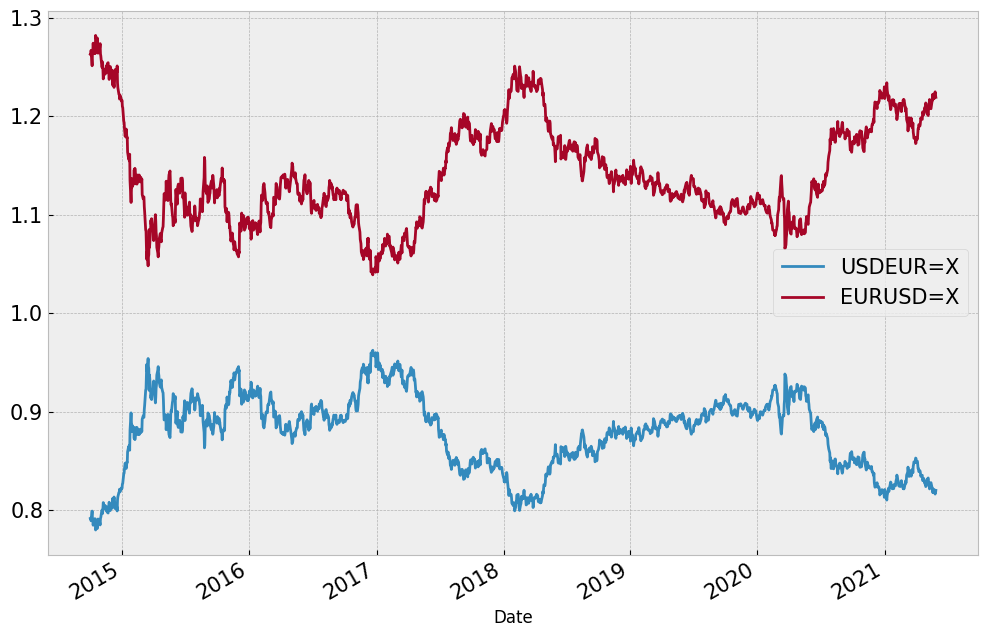

In [14]:
fx.plot(figsize=(12,8),fontsize=15)
plt.legend(fontsize=15)
plt.show()

In [16]:
simple_ret=fx.pct_change() # simple returns
simple_ret

,USDEUR=X,EURUSD=X
Date,,
2014-10-01,NaN,NaN
2014-10-02,0.000328,-0.000328
2014-10-03,-0.003661,0.003674
2014-10-06,0.012544,-0.012389
2014-10-07,-0.010474,0.010585
...,...,...
2021-05-24,0.003460,-0.003448
2021-05-25,-0.002571,0.002577
2021-05-26,-0.002813,0.002821


In [23]:
simple_ret.add(1).prod() # final multiple

USDEUR=X   1.035688
EURUSD=X   0.965542
dtype: float64

In [24]:
simple_ret.add(1).prod()-1 # compund simple returns

USDEUR=X    0.035688
EURUSD=X   -0.034458
dtype: float64

-> For simple returns: longe positions returns =! short positions returns * (-1)

In [25]:
log_ret=np.log(fx/fx.shift()) # Log returns
log_ret

,USDEUR=X,EURUSD=X
Date,,
2014-10-01,NaN,NaN
2014-10-02,0.000328,-0.000328
2014-10-03,-0.003668,0.003668
2014-10-06,0.012466,-0.012466
2014-10-07,-0.010529,0.010529
...,...,...
2021-05-24,0.003454,-0.003454
2021-05-25,-0.002574,0.002574
2021-05-26,-0.002817,0.002817


In [26]:
log_ret.sum() # cumulative Log returns

USDEUR=X    0.035066
EURUSD=X   -0.035066
dtype: float64

-> For log returns: long position returns == short position returns * (-1)

In [27]:
norm_fx=log_ret.cumsum().apply(np.exp) # normalized prices (Base 1)
norm_fx

,USDEUR=X,EURUSD=X
Date,,
2014-10-01,NaN,NaN
2014-10-02,1.000328,0.999672
2014-10-03,0.996666,1.003345
2014-10-06,1.009168,0.990915
2014-10-07,0.998598,1.001404
...,...,...
2021-05-24,1.036534,0.964754
2021-05-25,1.033869,0.967240
2021-05-26,1.030961,0.969969


In [28]:
norm_fx.iloc[0]=[1,1]

In [29]:
norm_fx

,USDEUR=X,EURUSD=X
Date,,
2014-10-01,1.000000,1.000000
2014-10-02,1.000328,0.999672
2014-10-03,0.996666,1.003345
2014-10-06,1.009168,0.990915
2014-10-07,0.998598,1.001404
...,...,...
2021-05-24,1.036534,0.964754
2021-05-25,1.033869,0.967240
2021-05-26,1.030961,0.969969


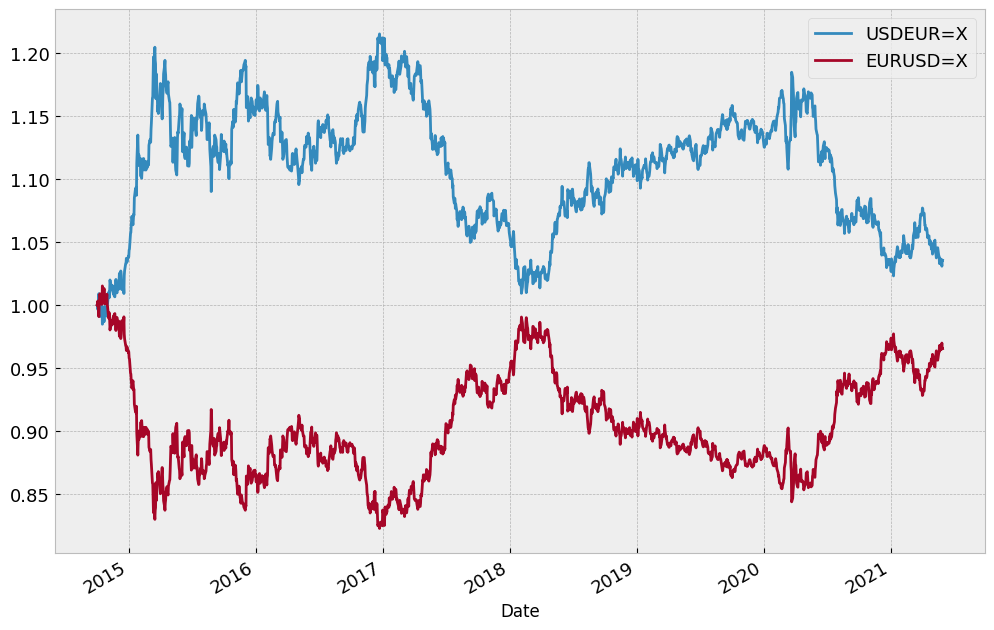

In [30]:
norm_fx.plot(figsize=(12,8),fontsize=13)
plt.legend(fontsize=13)
plt.show()